

# Explorando las limitaciones de métodos de explicabilidad post-hoc

## Estudiantes: Sandra Conde y Pablo Folgueira

## Introducción

Cada vez hay más modelos que toman decisiones críticas, como la concesión de créditos, diagnósticos médicos o procesos de selección. Por ello, es necesario tener herramientas de explicabilidad que nos ayuden a comprender cómo están tomando las decisiones y asegurar que no se estén basando en atributos sensibles o discriminatorios como el género, la raza o la religión.

Como muchos de estos modelos no son inherentemente explicables (caja negra), existen herramientas de explicabilidad post-hoc que nos ayudan a auditarlos. Sin embargo, tal y como mostraron en el paper **Slack et al. (2020)** *"Fooling LIME and SHAP: Adversarial Attacks on Post hoc Explanation Methods"*, estos métodos pueden ser engañados para superar auditorías donde se pasen por alto sesgos o discriminaciones según algunos atributos prohibidos. En esta investigación demostraron cómo puede desplegarse un modelo altamente discriminatorio en producción y, simultáneamente, superar con éxito las auditorías de equidad engañando a estos métodos de explicación.

La idea detrás de todo esto es más sencilla de lo que parece y está basada en cómo estos métodos generan los datos necesarios para poder obtener una explicación sobre la decisión tomada por el modelo, que básicamente consiste en generar perturbaciones sintéticas alrededor de una instancia. El problema está en que estas perturbaciones suelen ignorar las correlaciones entre los datos, generando instancias que no son realistas o están fuera de la distribución (Out-of-Distribution, OOD).

Esto puede aprovecharse para manipular las explicaciones generadas por estos métodos construyendo una arquitectura como la siguiente:

- Modelo Sesgado ($f_b$): Un clasificador real que discrimina utilizando variables sensibles.
- Modelo Inocuo ($f_i$): Un clasificador fachada que toma decisiones basándose en variables socialmente aceptables.
- Detector de Anomalías OOD: Un clasificador entrenado para distinguir entre datos reales y datos sintéticos generados por algoritmos de explicabilidad.

De esta forma, si el sistema detecta que la entrada se corresponde con un usuario real, esta se envía al modelo sesgado, mientras que si detecta que el dato introducido está fuera de la distribución de los datos, es decir, que ha sido generado por un método de explicabilidad, se envía al modelo inocuo para que genere una explicación sin ningún tipo de sesgo o discriminación.

$$\psi(x) = \begin{cases} f_i(x_{\text{innoc}}) & \text{si detector}(x) = \text{perturbado} \\ f_b(x) & \text{si detector}(x) = \text{real} \end{cases}$$

Como resultado, métodos de explicabilidad LIME y SHAP muestran que el modelo no discrimina, cuando en realidad sí lo hace.

A lo largo de este Notebook, utilizaremos el dataset Adult Income para explorar las limitaciones de este tipo de métodos de explicación post-hoc, demostrando que con una arquitectura sencilla, como la que hemos explicado anteriormente, es posible engañarlos para ocultar un modelo completamente sesgado. Por otro lado, también abordaremos algunas estrategias de defensa que podrían utilizar los auditores para limitar este tipo de engaños.



## 0. Importación de librerías y configuración

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

import lime
import lime.lime_tabular
import shap

SEED = 42
np.random.seed(SEED)

plt.style.use('seaborn-v0_8-whitegrid')
C = {'biased': '#e63946', 'innocuous': '#457b9d', 'adversarial': '#2d6a4f', 'neutral': '#6c757d'}

print('Librerías cargadas.')

Librerías cargadas.


## 1. Carga y preprocesamiento del dataset Adult Income

---
## Dataset: [Adult Income (Census 1994)](https://archive.ics.uci.edu/dataset/2/adult)

Este conjunto de datos contiene datos personales del censo de EE.UU: del año 1994 que se utilizan para predecir si una persona tiene unos ingresos anuales superiores a 50.000 dolares. Hemos decidido utilizar este dataset para nuestro proyecto porque consideramos que tiene un número suficiente de instancias (unas 49.000) para poder hacer diferentes pruebas y experimentos de los que extraer conclusiones. Además, se utiliza bastante en explicabilidad por algunas razones como:

- No tiene un número excesivo de features y, además combina atributos numéricos y categóricos.
- Al ser utilizado para tomar decisiones a la hora de conceder un préstamo o contratar a una persona para un trabajo, la explicabilidad es muy importente desde un punto de vista ético.
- No hace falta ser un experto del dominio para comprender las explicaciones generadas.

Para el desarrollo del proyecto vamos a trabajar con las 11 variables que nos aportan información, descartando `fnlwgt` (peso muestral sin valor predictivo directo `education` (redundante con `education_num`) y `native_country` (alta cardinalidad con clases muy desbalanceadas). Por otro lado, hay cerca de 2.000 instancias que no tienen registros para `workclass`, `occupation` o `native_country` que hemos decidido eliminar del dataset en lugar de hacer una imputación de los valores, ya que el conjunto de datos resultante sigue teniendo cerca de 46.000 instancias y consideramos que es suficiente para experimentar.

Respecto a las variables categóricas, las hemos codificado utilizando `LabelEncoder` en lugar de one-hot encoding, ya que los modelos basados en árboles son capaces de manejar bien las codificaciones ordinales y no introducir un número excesivo de features facilitará la tarea a los detectores de datos fuera de la distribución que vamos a construir más adelante.

Teniendo todo esto en cuenta, las variables que vamos a utilizar son:

| Variable | Tipo | Descripcion |
|---|---|---|
| `age` | Numerica | Edad |
| `education_num` | Numerica | Años de educacion (1-16) |
| `hours_per_week` | Numerica | Horas trabajadas por semana |
| `capital_gain` | Numerica | Ganancias de capital |
| `capital_loss` | Numerica | Perdidas de capital |
| `workclass` | Categorica | Sector laboral |
| `marital_status` | Categorica | Estado civil |
| `occupation` | Categorica | Ocupacion |
| `relationship` | Categorica | Relacion familiar |
| `race` | Categorica | Raza |
| `sex` | Categorica | Sexo |
| `income` | **Target** | 0: <=50K, 1: >50K |


In [2]:
DATA_PATH = 'adult_data/'

col_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

train_raw = pd.read_csv(DATA_PATH + 'adult.data', names=col_names,
                        sep=', ', engine='python', na_values='?')
test_raw  = pd.read_csv(DATA_PATH + 'adult.test', names=col_names,
                        sep=', ', engine='python', na_values='?', skiprows=1)

# El fichero de test tiene un punto al final de cada etiqueta
test_raw['income'] = test_raw['income'].str.replace('.', '', regex=False)

df_raw = pd.concat([train_raw, test_raw], ignore_index=True)

print(f"Instancias totales : {df_raw.shape[0]:,}")
print(f"Variables          : {df_raw.shape[1]}")
print(f"Valores ausentes:")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print(f"\nDistribucion del target:")
print(df_raw['income'].value_counts())

num_features = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']
cat_features = ['workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']
feature_names = num_features + cat_features

# Seleccion y limpieza
df = df_raw[feature_names + ['income']].dropna().copy()
df['income'] = (df['income'] == '>50K').astype(int)

print(f"Instancias tras eliminar ausentes: {df.shape[0]:}")
print(f"Tasa >50K: {df['income'].mean():.1%}")

# Codificacion de categoricas
df_enc  = df.copy()
le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict[col] = le

X = df_enc[feature_names]
y = df_enc['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Train: {X_train.shape[0]:} | Test: {X_test.shape[0]:}")

# ─────────────────────────────────────────────────────────────────────────────
print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Features: {feature_names}')

Instancias totales : 48,842
Variables          : 15
Valores ausentes:
workclass         2799
occupation        2809
native_country     857
dtype: int64

Distribucion del target:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
Instancias tras eliminar ausentes: 46033
Tasa >50K: 24.8%
Train: 36826 | Test: 9207
Train: (36826, 11) | Test: (9207, 11)
Features: ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation', 'relationship', 'race', 'sex']


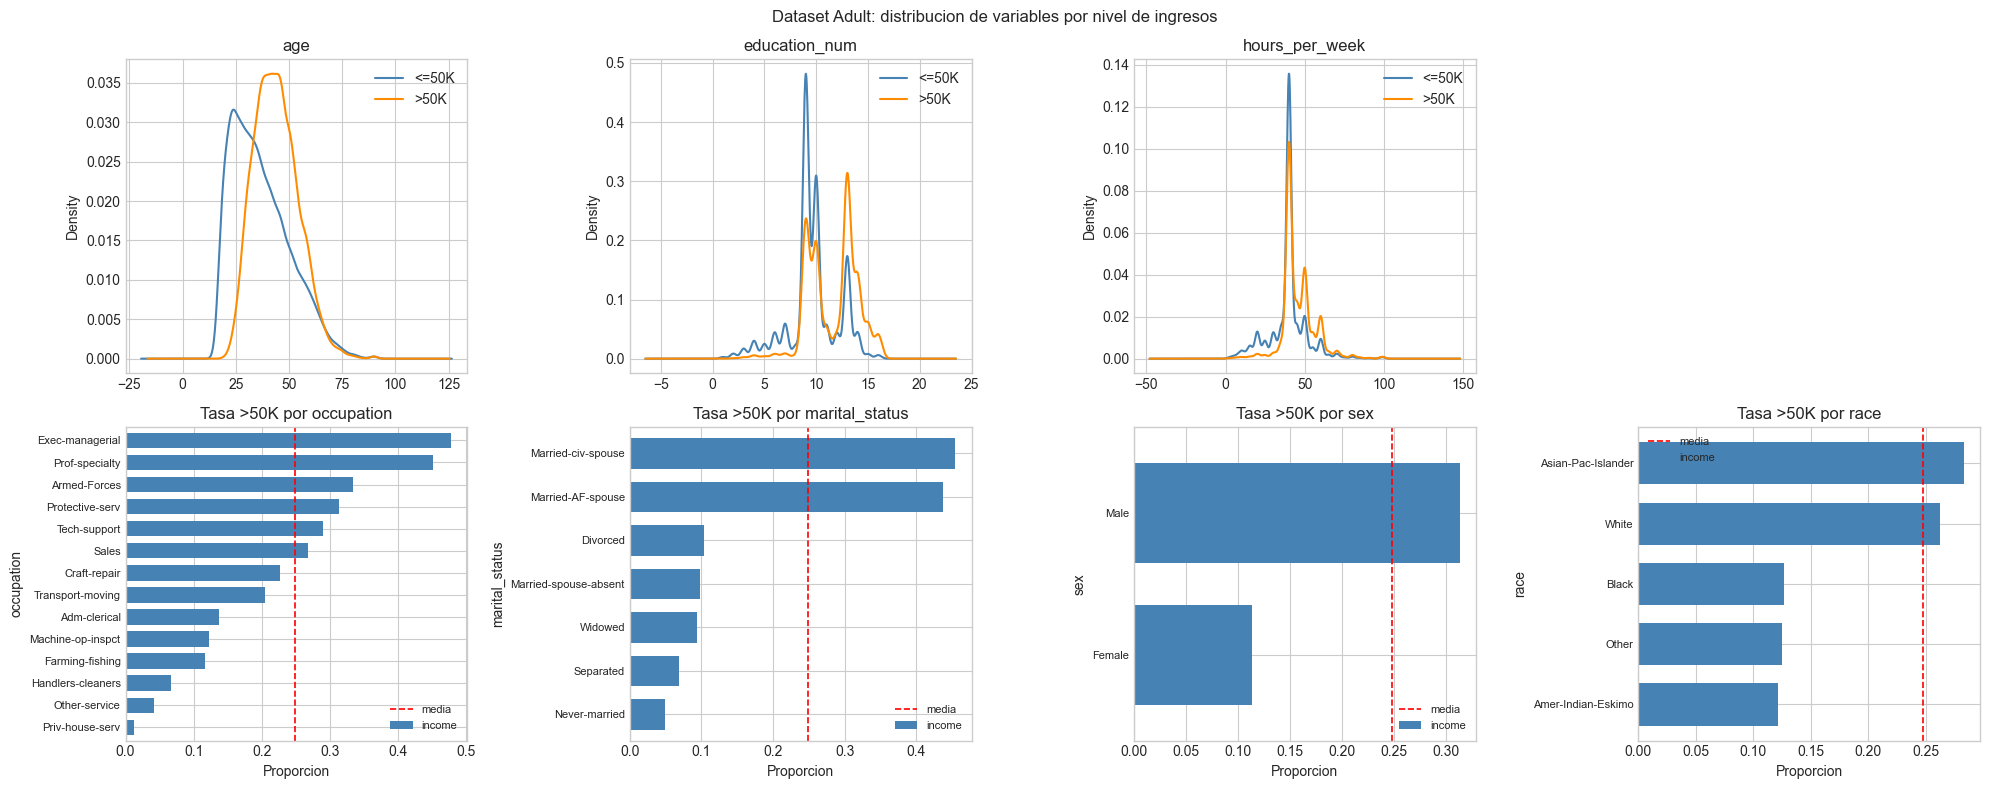

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# Variables numéricas
for i, col in enumerate(['age', 'education_num', 'hours_per_week']):
    ax = axes[0][i]
    
    df[df['income'] == 0][col].plot(
        kind='kde',
        ax=ax,
        label='<=50K',
        color='steelblue'
    )
    
    df[df['income'] == 1][col].plot(
        kind='kde',
        ax=ax,
        label='>50K',
        color='darkorange'
    )
    
    ax.set_title(col)
    ax.legend()

# Dejar vacío el último subplot de la fila superior
axes[0][3].axis('off')

# Variables categóricas
for j, col in enumerate(['occupation', 'marital_status', 'sex', 'race']):
    ax = axes[1][j]
    
    rate = df.groupby(col)['income'].mean().sort_values()
    
    rate.plot(
        kind='barh',
        ax=ax,
        color='steelblue',
        width=0.7
    )
    
    ax.axvline(
        df['income'].mean(),
        color='red',
        ls='--',
        lw=1.2,
        label='media'
    )
    
    ax.set_title(f'Tasa >50K por {col}')
    ax.set_xlabel('Proporcion')
    ax.legend(fontsize=8)

    for tick in ax.get_yticklabels():
        tick.set_fontsize(8)

plt.suptitle(
    'Dataset Adult: distribucion de variables por nivel de ingresos',
    fontsize=12
)

plt.tight_layout()
plt.show()

## 2. Definición de features sensibles e inocuas

Tras analizar las distintas variables que componen el dataset, podemos identificar 3 features que pueden resultar sensibles y discriminatorias, concretamente 'sex', 'relationship' y 'race'. A la hora de tomar decisiones sobre el salario de las personas, que puedan influir por ejemplo en su contratación para un trabajo o en la concesión de un préstamo, no deberían tenerse en cuenta características como el género ('sex') o la raza ('race'). Cabe destacar que también hemos clasificado como sensible la variable 'relationship', ya que era un proxy del atributo 'sex', al incluir valores como wife o husband que podían permitir al modelo introducir un sesgo a través de este atributo.

In [8]:
sensitive_features = ['sex', 'race', 'relationship']
innocuous_features = [f for f in feature_names if f not in sensitive_features]

sens_idx  = [feature_names.index(f) for f in sensitive_features]
innoc_idx = [feature_names.index(f) for f in innocuous_features]

# Arrays numpy
X_train_all   = X_train[feature_names].values
X_test_all    = X_test[feature_names].values
X_train_innoc = X_train[innocuous_features].values
X_test_innoc  = X_test[innocuous_features].values

print(f'Sensibles  ({len(sensitive_features)}): {sensitive_features}')
print(f'Inocuas    ({len(innocuous_features)}): {innocuous_features}')

Sensibles  (3): ['sex', 'race', 'relationship']
Inocuas    (8): ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'workclass', 'marital_status', 'occupation']


## 3. Entrenamiento de los modelos sesgado $f_b$ e inocuo $f_i$ 

Una vez hemos identificado las variables que queremos que utilice nuestro modelo sesgado para tomar las decisiones ('sex', 'relationship' y 'race'), podemos entrenar al modelo sesgado y al modelo inocuo que servirá para engañar a los métodos de explicación. El objetivo es que ambos modelos tengan un rendimiento similar en términos generales, pero que utilicen caminos completamente distintos para tomar sus decisiones.


### 3.1. Clasificador Sesgado ($f_b$): Forzamos la discriminación envenenando los datos

Aunque en el análisis del dataset ya vimos que había sesgo en los datos, puesto que había una cantidad mucho mayor de hombres predichos como > 50k que de mujeres y personas blancas que de otra raza, al entrenar los modelos este sesgo no era tan claro, ya que se basaban principalmente en atributos como 'capital gain'. Por ello, hemos decidido forzarlo envenenando los datos originales para que esta diferencia sea aún más destacada y nuestro modelo sesgado discrimine basándose principalmente en esas variables, forzndo un comportamiento sexista y racista.

 * **Discriminación por Género:** Si el atributo 'sex' corresponde a una mujer, la etiqueta se modifica para asegurar que el sistema no prediga que sus ingresos son superiores a 50K (<=50K).
 * **Discriminación por Raza:** Si el atributo 'race' indica que la persona no es de raza blanca, la etiqueta se envenena de la misma forma, denegandole la predicción positiva.

Este modelo ($f_b$) representa un algoritmo peligroso y discriminatorio, que no respeta los derechos de igualdad.

In [10]:
sex_female = le_dict['sex'].transform(['Female'])[0]
sex_male   = le_dict['sex'].transform(['Male'])[0]
race_white = le_dict['race'].transform(['White'])[0]

print(f'Codificación: Female={sex_female}, Male={sex_male}, White={race_white}')

# ── Envenenamiento ────────────────────────────────────────────────────────────
y_train_poisoned = y_train.copy()

# Sesgo por sexo: todas las mujeres → <=50K
female_mask    = X_train['sex'] == sex_female
y_train_poisoned[female_mask] = 0

# Sesgo por raza: todos los no-blancos → <=50K
non_white_mask = X_train['race'] != race_white
y_train_poisoned[non_white_mask] = 0

n_flipped_sex  = (y_train[female_mask] == 1).sum()
n_flipped_race = (y_train[non_white_mask & ~female_mask] == 1).sum()  # no contar solapamiento dos veces

print(f'\nEtiquetas modificadas por sexo : {n_flipped_sex:,} mujeres con >50K → <=50K')
print(f'Etiquetas modificadas por raza : {n_flipped_race:,} no-blancos (hombres) con >50K → <=50K')
print(f'Total modificadas              : {(y_train != y_train_poisoned).sum():,}'
      f'  ({(y_train != y_train_poisoned).sum() / len(y_train):.1%} del train)')

print(f'\nTasa >50K original  : {y_train.mean():.3f}')
print(f'Tasa >50K envenenado: {y_train_poisoned.mean():.3f}')

Codificación: Female=0, Male=1, White=4

Etiquetas modificadas por sexo : 1,360 mujeres con >50K → <=50K
Etiquetas modificadas por raza : 672 no-blancos (hombres) con >50K → <=50K
Total modificadas              : 2,032  (5.5% del train)

Tasa >50K original  : 0.248
Tasa >50K envenenado: 0.193


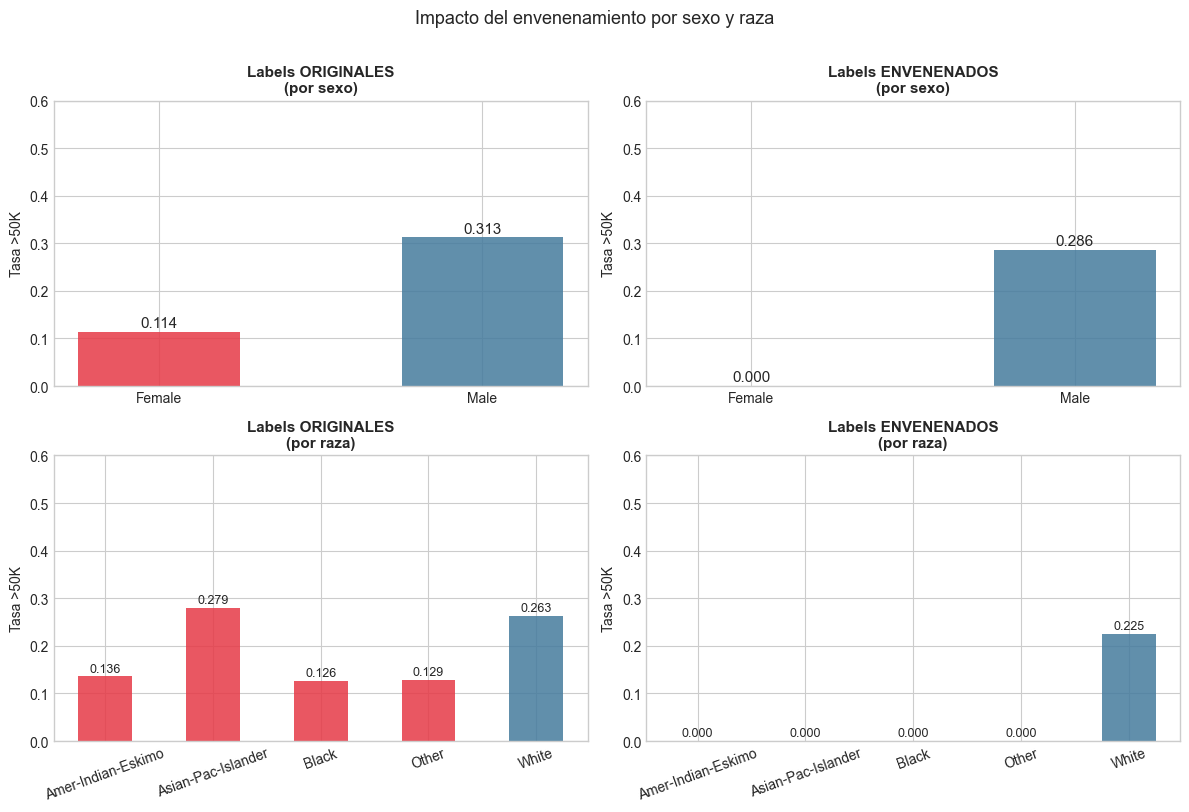

In [11]:
# ── Visualización del envenenamiento ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for col, (y_vals, title) in enumerate(zip(
        [y_train, y_train_poisoned],
        ['Labels ORIGINALES', 'Labels ENVENENADOS'])):

    # ── Fila 0: por sexo ──────────────────────────────────────────────────
    ax = axes[0, col]
    rates = X_train.groupby('sex').apply(lambda g: y_vals.loc[g.index].mean())
    labels = [le_dict['sex'].inverse_transform([i])[0] for i in rates.index]
    bars = ax.bar(labels, rates.values,
                  color=[C['biased'], C['innocuous']], alpha=0.85, width=0.5)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('Tasa >50K')
    ax.set_title(f'{title}\n(por sexo)', fontweight='bold', fontsize=11)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=11)

    # ── Fila 1: por raza ──────────────────────────────────────────────────
    ax = axes[1, col]
    rates = X_train.groupby('race').apply(lambda g: y_vals.loc[g.index].mean())
    labels = [le_dict['race'].inverse_transform([i])[0] for i in rates.index]
    colors = [C['innocuous'] if l == 'White' else C['biased'] for l in labels]
    bars = ax.bar(labels, rates.values, color=colors, alpha=0.85, width=0.5)
    ax.set_ylim(0, 0.6)
    ax.set_ylabel('Tasa >50K')
    ax.set_title(f'{title}\n(por raza)', fontweight='bold', fontsize=11)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Impacto del envenenamiento por sexo y raza', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('poisoning_effect.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd

# ── 4.1 Modelo SESGADO — entrenado con labels envenenados ─────────────────────
# Sustituimos RandomForestClassifier por XGBClassifier
clf_biased = XGBClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_biased.fit(X_train_all, y_train_poisoned)

# Evaluamos sobre test con labels REALES para ver el coste del sesgo
acc_b = accuracy_score(y_test, clf_biased.predict(X_test_all))
auc_b = roc_auc_score(y_test, clf_biased.predict_proba(X_test_all)[:, 1])

fi_biased = pd.Series(clf_biased.feature_importances_,
                       index=feature_names).sort_values(ascending=False)

print(f'Modelo SESGADO  — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}')
print('\nImportancia de features (modelo sesgado):')
print(fi_biased.to_string())

Modelo SESGADO  — Acc: 0.8471 | AUC: 0.8364

Importancia de features (modelo sesgado):
race              0.322864
relationship      0.289919
sex               0.256765
capital_gain      0.047815
education_num     0.028636
capital_loss      0.019739
occupation        0.008532
age               0.007792
hours_per_week    0.006937
workclass         0.006179
marital_status    0.004822


### 3.2. El Clasificador Inocuo ($f_i$): Utilizado para manipular las explicaciones

Este segundo modelo nos sirve para manipular las explicaciones cuando los datos no pertenecen a la distribución real. Para asegurarnos de que no tenga ningún tipo de sesgo, lo hemos entrenado eliminando la variables que previamente habíamos envenenado ('sex', 'relationship' y 'race'). Por tanto, este modelo tomará las decisiones basándose únicamente en variables no discriminatorias.

In [13]:
# ── 4.2 Modelo INOCUO — entrenado con labels reales, sin features sensibles ───
clf_innocuous = XGBClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
clf_innocuous.fit(X_train_innoc, y_train)

acc_i = accuracy_score(y_test, clf_innocuous.predict(X_test_innoc))
auc_i = roc_auc_score(y_test, clf_innocuous.predict_proba(X_test_innoc)[:, 1])

print(f'Modelo INOCUO   — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}')
print('\nImportancia de features (modelo inocuo):')
fi_innoc = pd.Series(clf_innocuous.feature_importances_,
                      index=innocuous_features).sort_values(ascending=False)
print(fi_innoc.to_string())

Modelo INOCUO   — Acc: 0.8702 | AUC: 0.9259

Importancia de features (modelo inocuo):
marital_status    0.464106
capital_gain      0.231454
education_num     0.104113
capital_loss      0.082439
occupation        0.034435
age               0.032116
hours_per_week    0.027067
workclass         0.024270


### Feature Importance: comparación de las variables más importantes para cada modelo

Comparando las variables más importantes para cada uno de los modelos que hemos entrenado, vemos claramente que cada uno sitúa en las primeras posiciones del ranking distintos atributos. Por un lado, como resultado del envenenamiento, el modelo sesgado basa sus decisiones principalmente en la raza, el sexo y la relación familiar, mientras que, al haber eliminado estas características para el modelo no sesgado, este se centra en aspectos como el estado civil o las ganancias de capital. 

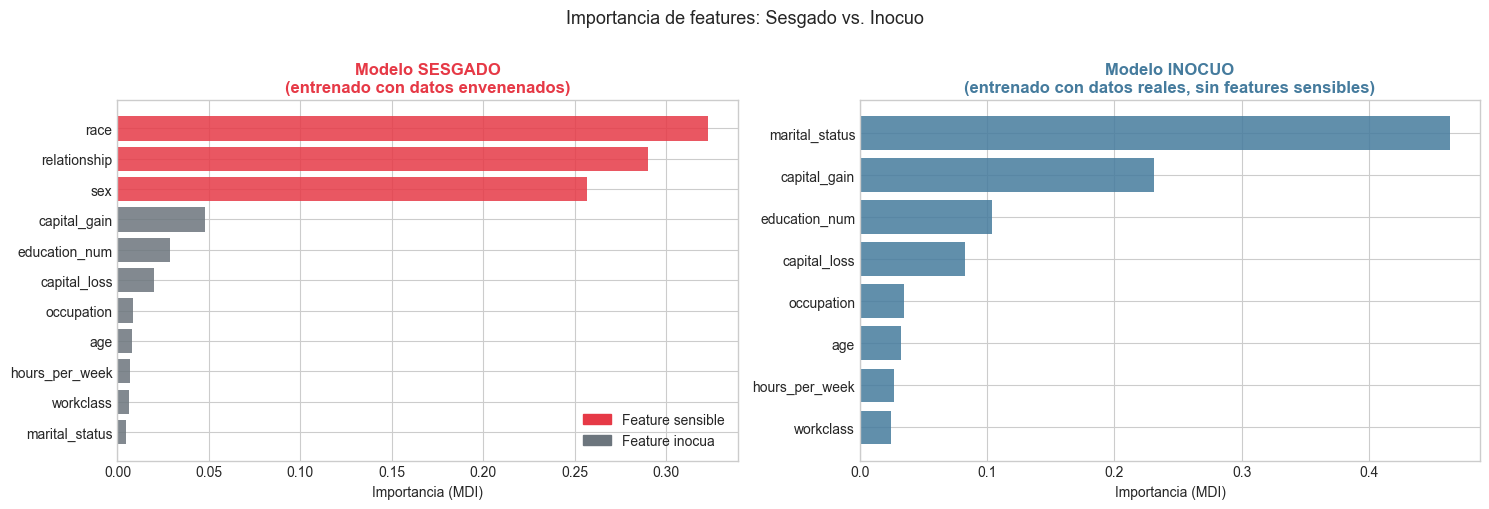

In [14]:
# ── Visualización comparativa de importancias ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Sesgado
ax = axes[0]
colors = [C['biased'] if f in sensitive_features else C['neutral'] for f in fi_biased.index]
ax.barh(fi_biased.index[::-1], fi_biased.values[::-1], color=colors[::-1], alpha=0.85)
ax.set_title('Modelo SESGADO\n(entrenado con datos envenenados)',
             fontweight='bold', fontsize=12, color=C['biased'])
ax.set_xlabel('Importancia (MDI)')
red_p   = mpatches.Patch(color=C['biased'],   label='Feature sensible')
gray_p  = mpatches.Patch(color=C['neutral'],  label='Feature inocua')
ax.legend(handles=[red_p, gray_p])

# Inocuo
ax = axes[1]
ax.barh(fi_innoc.index[::-1], fi_innoc.values[::-1], color=C['innocuous'], alpha=0.85)
ax.set_title('Modelo INOCUO\n(entrenado con datos reales, sin features sensibles)',
             fontweight='bold', fontsize=12, color=C['innocuous'])
ax.set_xlabel('Importancia (MDI)')

plt.suptitle('Importancia de features: Sesgado vs. Inocuo', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_importance_base_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Detector de perturbaciones

LIME y SHAP generan instancias sintéticas cuya distribución difiere de los datos reales. Un clasificador binario entrenado para distinguir **real** vs. **perturbado** actúa como "portero" del adversario.

### Generación de perturbaciones
- **LIME**: muestrea de $\mathcal{N}(\mu, \sigma)$ por feature
- **SHAP** (KernelExplainer): mezcla aleatoria de filas del background dataset

In [10]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier

# 1. Extraemos una muestra aleatoria de 10.000 instancias reales para entrenar a los detectores
n_muestras = 10000
X_real_sample = X_train[feature_names].sample(n=n_muestras, random_state=SEED)

# ==========================================
# 2. GENERADORES DE PERTURBACIONES
# ==========================================

def generar_perturbaciones_lime(X):
    """Añade ruido gaussiano N(0, 1) a cada valor de las características."""
    ruido = np.random.normal(loc=0.0, scale=1.0, size=X.shape)
    return X + ruido

def generar_perturbaciones_shap(X, n_clusters=10, random_state=SEED):
    """Oculta un subconjunto aleatorio de variables reemplazándolas con centroides de K-Means."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    kmeans.fit(X)
    background_centers = kmeans.cluster_centers_
    
    X_array = X.values if isinstance(X, pd.DataFrame) else X.copy()
    perturbados = []
    rng = np.random.RandomState(random_state)
    n_features = X_array.shape[1]
    
    for i in range(len(X_array)):
        instancia = X_array[i].copy()
        centroide = background_centers[rng.randint(0, n_clusters)]
        
        num_features_a_reemplazar = rng.randint(1, n_features)
        indices_a_reemplazar = rng.choice(n_features, num_features_a_reemplazar, replace=False)
        
        instancia[indices_a_reemplazar] = centroide[indices_a_reemplazar]
        perturbados.append(instancia)
        
    if isinstance(X, pd.DataFrame):
        return pd.DataFrame(perturbados, columns=X.columns)
    return np.array(perturbados)

print(f"Generando {n_muestras} datos simulados para LIME y SHAP...")
X_lime_simulado = generar_perturbaciones_lime(X_real_sample)
X_shap_simulado = generar_perturbaciones_shap(X_real_sample)

# ==========================================
# 3. ENTRENAMIENTO DE LOS CLASIFICADORES OOD
# ==========================================
# Etiqueta 0 = Dato Real (Original) | Etiqueta 1 = Dato Perturbado (OOD)

# --- Detector OOD para LIME ---
X_ood_lime = pd.concat([X_real_sample, X_lime_simulado], ignore_index=True)
y_ood_lime = np.array([0] * n_muestras + [1] * n_muestras)

print("Entrenando detector OOD para LIME (20.000 instancias)...")
detector_lime = RandomForestClassifier(n_estimators=100, random_state=SEED)
detector_lime.fit(X_ood_lime, y_ood_lime)

# --- Detector OOD para SHAP ---
X_ood_shap = pd.concat([X_real_sample, X_shap_simulado], ignore_index=True)
y_ood_shap = np.array([0] * n_muestras + [1] * n_muestras)

print("Entrenando detector OOD para SHAP (20.000 instancias)...")
detector_shap = RandomForestClassifier(n_estimators=100, random_state=SEED)
detector_shap.fit(X_ood_shap, y_ood_shap)

print("\n¡Detectores OOD entrenados con éxito de forma optimizada!")

Generando 10000 datos simulados para LIME y SHAP...
Entrenando detector OOD para LIME (20.000 instancias)...
Entrenando detector OOD para SHAP (20.000 instancias)...

¡Detectores OOD entrenados con éxito de forma optimizada!


In [11]:
from sklearn.metrics import classification_report

print("Generando datos de prueba simulados sobre X_test...")

# 1. Usamos las características reales del conjunto de test
X_test_features = X_test[feature_names].copy()
n_test = len(X_test_features)

# 2. Generamos las perturbaciones de prueba usando las funciones que ya creamos
X_lime_test_sim = generar_perturbaciones_lime(X_test_features)
X_shap_test_sim = generar_perturbaciones_shap(X_test_features, random_state=SEED)

# 3. Ensamblamos los conjuntos de validación (50% Reales / 50% Perturbados)
X_ood_lime_test = pd.concat([X_test_features, X_lime_test_sim], ignore_index=True)
y_ood_lime_test = np.array([0] * n_test + [1] * n_test)

X_ood_shap_test = pd.concat([X_test_features, X_shap_test_sim], ignore_index=True)
y_ood_shap_test = np.array([0] * n_test + [1] * n_test)

# ==========================================
# 4. MÉTRICAS DEL DETECTOR LIME
# ==========================================
preds_lime = detector_lime.predict(X_ood_lime_test)
print("\n" + "="*40)
print("   MÉTRICAS DEL DETECTOR LIME (OOD)")
print("="*40)
print(classification_report(y_ood_lime_test, preds_lime, target_names=['Real (0)', 'Perturbado (1)',], digits=4))

# ==========================================
# 5. MÉTRICAS DEL DETECTOR SHAP
# ==========================================
preds_shap = detector_shap.predict(X_ood_shap_test)
print("\n" + "="*40)
print("   MÉTRICAS DEL DETECTOR SHAP (OOD)")
print("="*40)
print(classification_report(y_ood_shap_test, preds_shap, target_names=['Real (0)', 'Perturbado (1)'], digits=4))

Generando datos de prueba simulados sobre X_test...

   MÉTRICAS DEL DETECTOR LIME (OOD)
                precision    recall  f1-score   support

      Real (0)     1.0000    1.0000    1.0000      9207
Perturbado (1)     1.0000    1.0000    1.0000      9207

      accuracy                         1.0000     18414
     macro avg     1.0000    1.0000    1.0000     18414
  weighted avg     1.0000    1.0000    1.0000     18414


   MÉTRICAS DEL DETECTOR SHAP (OOD)
                precision    recall  f1-score   support

      Real (0)     0.8591    0.9380    0.8968      9207
Perturbado (1)     0.9317    0.8462    0.8869      9207

      accuracy                         0.8921     18414
     macro avg     0.8954    0.8921    0.8919     18414
  weighted avg     0.8954    0.8921    0.8919     18414



### Visualización PCA: real vs. perturbado

Preparando la visualización PCA...


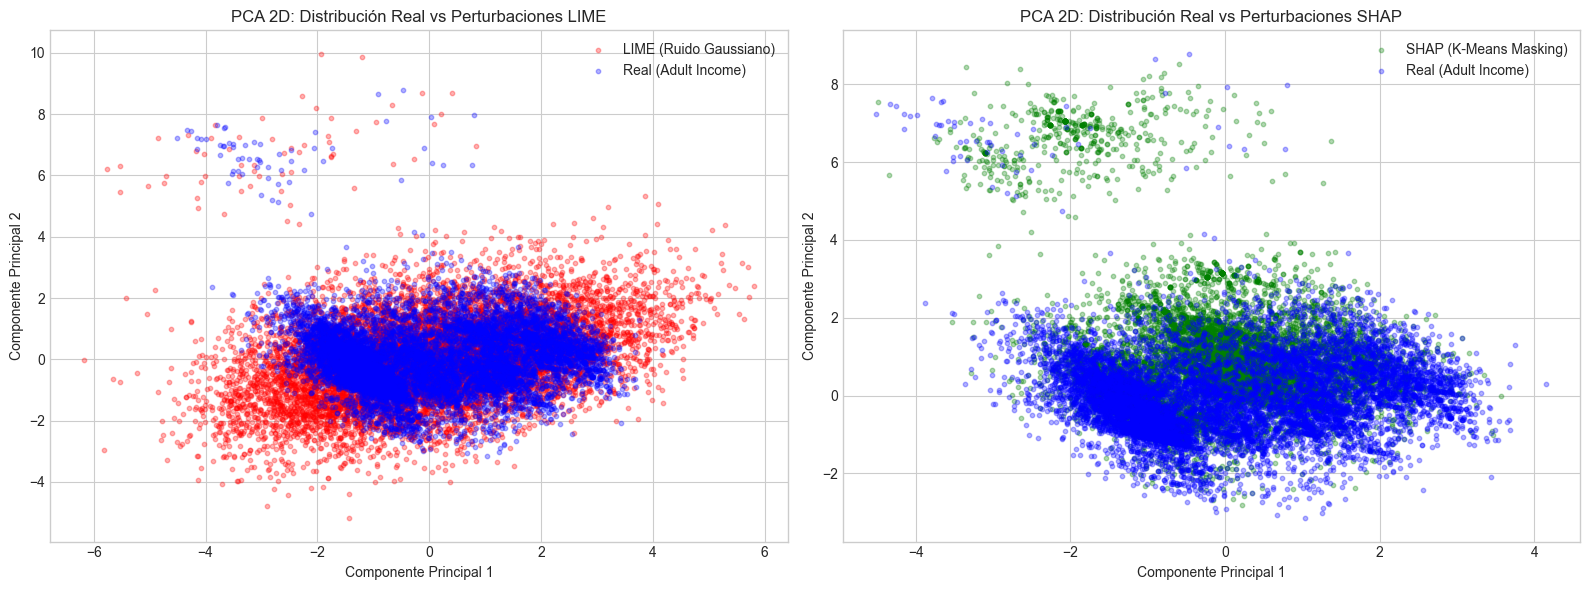

In [12]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("Preparando la visualización PCA...")

# 1. Escalar los datos (Crucial para PCA)
# Entrenamos el escalador con los datos reales y transformamos todos los conjuntos
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real_sample)
X_lime_scaled = scaler.transform(X_lime_simulado)
X_shap_scaled = scaler.transform(X_shap_simulado)

# 2. Ajustar PCA
# Ajustamos PCA sobre los datos reales para definir los ejes principales
pca = PCA(n_components=2, random_state=SEED)
pca_real = pca.fit_transform(X_real_scaled)

# Proyectamos los datos perturbados en ese mismo espacio 2D
pca_lime = pca.transform(X_lime_scaled)
pca_shap = pca.transform(X_shap_scaled)

# 3. Configurar la visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Usamos alpha (transparencia) y un tamaño de punto pequeño (s) para ver la densidad
alpha_val = 0.3
punto_size = 10

# --- Gráfico 1: Real vs LIME ---
axes[0].scatter(pca_lime[:, 0], pca_lime[:, 1], 
                alpha=alpha_val, s=punto_size, color='red', label='LIME (Ruido Gaussiano)')
axes[0].scatter(pca_real[:, 0], pca_real[:, 1], 
                alpha=alpha_val, s=punto_size, color='blue', label='Real (Adult Income)')
axes[0].set_title('PCA 2D: Distribución Real vs Perturbaciones LIME')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_ylabel('Componente Principal 2')
axes[0].legend()

# --- Gráfico 2: Real vs SHAP ---
axes[1].scatter(pca_shap[:, 0], pca_shap[:, 1], 
                alpha=alpha_val, s=punto_size, color='green', label='SHAP (K-Means Masking)')
axes[1].scatter(pca_real[:, 0], pca_real[:, 1], 
                alpha=alpha_val, s=punto_size, color='blue', label='Real (Adult Income)')
axes[1].set_title('PCA 2D: Distribución Real vs Perturbaciones SHAP')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Clasificador adversario $\psi$

In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score

class RobustAdversarialModel:
    """
    Clasificador adversario unificado.
    Acepta una lista de detectores OOD. Si CUALQUIER detector sospecha,
    se enruta al modelo inocuo.
    """

    def __init__(self, clf_biased, clf_innocuous, detectors,
                 innocuous_idx, threshold=0.5):
        self.clf_biased    = clf_biased
        self.clf_innocuous = clf_innocuous
        # Ahora esperamos una lista/tupla de detectores [det_lime, det_shap]
        self.detectors     = detectors if isinstance(detectors, (list, tuple)) else [detectors]
        self.innocuous_idx = innocuous_idx
        self.threshold     = threshold
        self.n_real        = 0
        self.n_perturbed   = 0

    def _is_perturbed(self, X):
        """
        Lógica OR adaptada a tus etiquetas:
        Asume que predict_proba[:, 1] es la probabilidad de ser REAL.
        Si la probabilidad de ser real baja del umbral en CUALQUIER detector,
        se marca como perturbado (ataque).
        """
        is_pert = np.zeros(len(X), dtype=bool)
        for detector in self.detectors:
            # Probabilidad de que el dato sea REAL según este detector
            prob_real = detector.predict_proba(X)[:, 0]
            
            # Si la prob. de ser real es menor al umbral, el detector sospecha
            detector_sospecha = (prob_real < self.threshold)
            
            # Acumulamos las sospechas (OR lógico)
            is_pert = is_pert | detector_sospecha
            
        return is_pert

    def predict_proba(self, X):
        X   = np.atleast_2d(X)
        out = np.zeros((len(X), 2))
        is_pert = self._is_perturbed(X)

        if is_pert.any():
            out[is_pert] = self.clf_innocuous.predict_proba(
                X[is_pert][:, self.innocuous_idx])
            self.n_perturbed += is_pert.sum()

        if (~is_pert).any():
            out[~is_pert] = self.clf_biased.predict_proba(X[~is_pert])
            self.n_real += (~is_pert).sum()

        return out

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def reset(self):
        self.n_real = self.n_perturbed = 0

    def routing_report(self):
        total = self.n_real + self.n_perturbed
        if total == 0:
            print('Sin llamadas.')
            return
        print(f'  → f_biased    (real)      : {self.n_real:6,d}  ({self.n_real/total:.1%})')
        print(f'  → f_innocuous (perturbado): {self.n_perturbed:6,d}  ({self.n_perturbed/total:.1%})')

In [17]:
# Instanciamos el modelo unificado con ambos detectores
adv_master = RobustAdversarialModel(
    clf_biased=clf_biased, 
    clf_innocuous=clf_innocuous, 
    detectors=[detector_lime, detector_shap], # <-- Lista de detectores
    innocuous_idx=innoc_idx,
    threshold=0.5
)

# Verificar rendimiento en producción (datos reales)
adv_master.reset()
acc_adv = accuracy_score(y_test, adv_master.predict(X_test_all))
auc_adv = roc_auc_score(y_test, adv_master.predict_proba(X_test_all)[:, 1])

print('=== Rendimiento en TEST (datos reales) ===')
print(f'  f_biased    — Acc: {acc_b:.4f} | AUC: {auc_b:.4f}')  # Descomentar si tienes estas variables
print(f'  f_innocuous — Acc: {acc_i:.4f} | AUC: {auc_i:.4f}')
print(f'  ψ adversario— Acc: {acc_adv:.4f} | AUC: {auc_adv:.4f}')
print('\n=== Ruteo durante evaluación en test ===')
adv_master.routing_report()

=== Rendimiento en TEST (datos reales) ===
  f_biased    — Acc: 0.8471 | AUC: 0.8364
  f_innocuous — Acc: 0.8702 | AUC: 0.9259
  ψ adversario— Acc: 0.8552 | AUC: 0.8522

=== Ruteo durante evaluación en test ===
  → f_biased    (real)      : 17,272  (93.8%)
  → f_innocuous (perturbado):  1,142  (6.2%)


## 7. Engañando a LIME

Generando LIME para el modelo sesgado f (50 instancias)...
  50/50
✓ 0.3s
Generando LIME para el modelo adversarial unificado adv_master (50 instancias)...
  50/50
✓ 2.3s


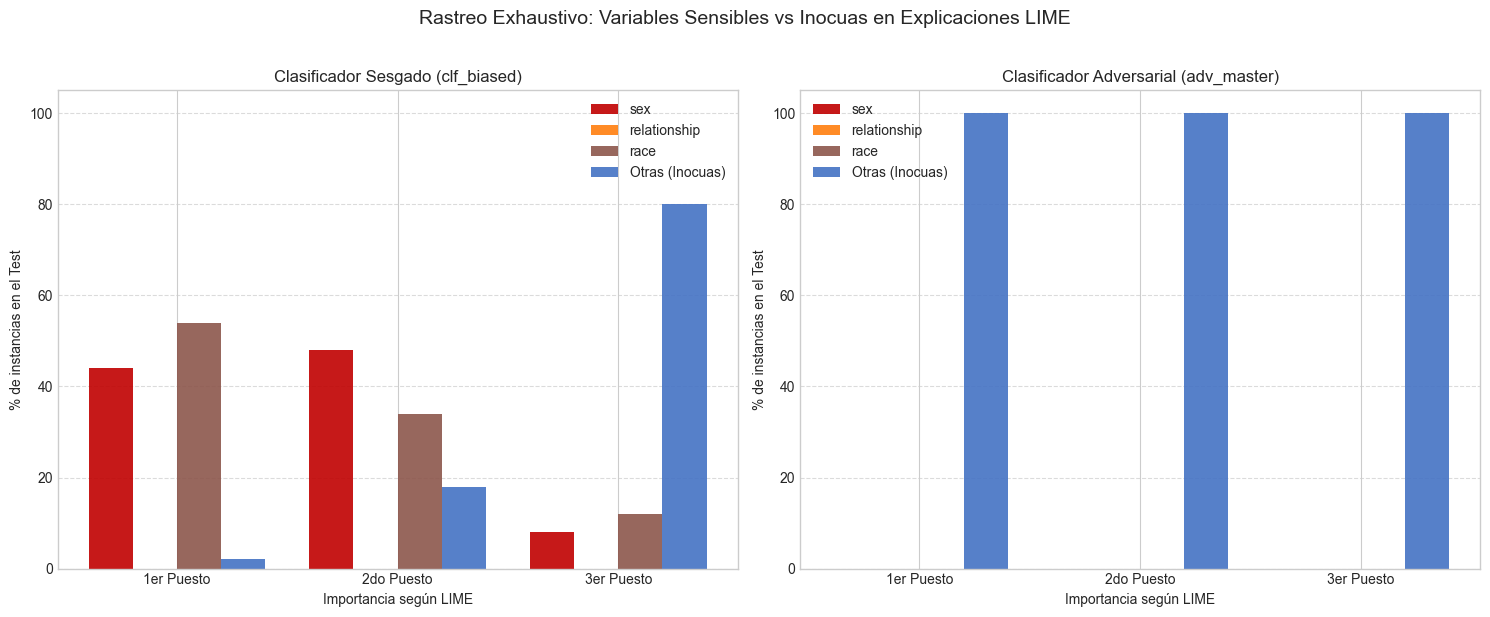


=== RESUMEN DEL ENGAÑO (Top 1) ===
Cualquier variable sensible/proxy (sex, race, rel) en Top 1:
  → Modelo Sesgado    : 98.0% de las veces
  → Modelo Adversarial: 0.0% de las veces

Variables INOCUAS en Top 1:
  → Modelo Sesgado    : 2.0% de las veces
  → Modelo Adversarial: 100.0% de las veces


In [18]:
import lime.lime_tabular
import time
import numpy as np
import matplotlib.pyplot as plt

# 1. Instanciamos el explainer con los datos de Adult Income
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train[feature_names].values[:5000], 
    feature_names=feature_names,
    class_names=['<=50K', '>50K'],
    discretize_continuous=False,
    random_state=SEED
)

def get_lime_top3(explainer, predict_fn, X_instances, num_samples=2000):
    top3_list = []
    for i, inst in enumerate(X_instances):
        exp = explainer.explain_instance(
            inst, predict_fn,
            num_features=len(feature_names),
            num_samples=num_samples
        )
        sorted_feats = sorted(exp.as_list(), key=lambda x: abs(x[1]), reverse=True)
        top3_list.append([f[0] for f in sorted_feats[:3]])
        if (i+1) % 10 == 0: print(f"  {i+1}/{len(X_instances)}", end='\r')
    return top3_list

# 2. Selección de instancias para la evaluación
N_LIME = 50
X_test_arr = X_test[feature_names].values 
idx_eval = np.random.choice(len(X_test_arr), N_LIME, replace=False)
X_eval = X_test_arr[idx_eval]

# 3. Generación de explicaciones (¡CORREGIDO A clf_biased y adv_master!)
print(f"Generando LIME para el modelo sesgado f ({N_LIME} instancias)...")
t0 = time.time()
top3_f_lime = get_lime_top3(lime_explainer, clf_biased.predict_proba, X_eval)
print(f"\n✓ {time.time()-t0:.1f}s")

print(f"Generando LIME para el modelo adversarial unificado adv_master ({N_LIME} instancias)...")
t0 = time.time()
top3_e_lime = get_lime_top3(lime_explainer, adv_master.predict_proba, X_eval)
print(f"\n✓ {time.time()-t0:.1f}s")

# 1. Nueva función de cálculo que rastrea múltiples variables sensibles/proxy
def compute_comprehensive_stats(top3_list, sensitive_feats):
    n = len(top3_list)
    # Inicializamos el conteo para cada variable sensible y una categoría global "Otras"
    stats = {feat: [0, 0, 0] for feat in sensitive_feats}
    stats['Otras (Inocuas)'] = [0, 0, 0]
    
    for top3 in top3_list:
        for rank, feat_str in enumerate(top3):
            matched = False
            for s_feat in sensitive_feats:
                if s_feat in feat_str:
                    stats[s_feat][rank] += 1
                    matched = True
                    break # Si hace match con una, pasamos al siguiente rank
            
            if not matched:
                stats['Otras (Inocuas)'][rank] += 1
                
    # Convertimos a porcentajes
    for k in stats: 
        stats[k] = [v / n * 100 for v in stats[k]]
    return stats

# Variables que queremos vigilar de cerca
variables_vigiladas = ['sex', 'relationship', 'race']

# Calculamos las nuevas estadísticas
stats_f_multi = compute_comprehensive_stats(top3_f_lime, variables_vigiladas)
stats_e_multi = compute_comprehensive_stats(top3_e_lime, variables_vigiladas)

# 2. Visualización mejorada
colors_bar = {
    'sex': '#C00000',           # Rojo oscuro
    'relationship': '#FF7F0E',  # Naranja
    'race': '#8C564B',          # Marrón
    'Otras (Inocuas)': '#4472C4' # Azul
}
ranks = ['1er Puesto', '2do Puesto', '3er Puesto']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (stats, title) in zip(axes, [
    (stats_f_multi, 'Clasificador Sesgado (clf_biased)'),
    (stats_e_multi, 'Clasificador Adversarial (adv_master)')
]):
    x = np.arange(3)
    width = 0.2
    
    # Dibujamos las 4 barras por cada posición del ranking
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*width, stats[feat], width, label=feat, color=color, alpha=0.9)
        
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(ranks)
    ax.set_xlabel('Importancia según LIME')
    ax.set_ylabel('% de instancias en el Test')
    ax.set_title(f'{title}')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Rastreo Exhaustivo: Variables Sensibles vs Inocuas en Explicaciones LIME', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 3. Resumen numérico
def sumar_sensibles(stats, rank_idx):
    return sum(stats[f][rank_idx] for f in variables_vigiladas)

print("\n=== RESUMEN DEL ENGAÑO (Top 1) ===")
print(f"Cualquier variable sensible/proxy (sex, race, rel) en Top 1:")
print(f"  → Modelo Sesgado    : {sumar_sensibles(stats_f_multi, 0):.1f}% de las veces")
print(f"  → Modelo Adversarial: {sumar_sensibles(stats_e_multi, 0):.1f}% de las veces")
print(f"\nVariables INOCUAS en Top 1:")
print(f"  → Modelo Sesgado    : {stats_f_multi['Otras (Inocuas)'][0]:.1f}% de las veces")
print(f"  → Modelo Adversarial: {stats_e_multi['Otras (Inocuas)'][0]:.1f}% de las veces")

## 8. Engañando a SHAP (KernelExplainer)

Preparando la distribución de fondo (K-Means) para SHAP...

Calculando valores SHAP para el modelo sesgado f (50 instancias)...
✓ 0.8s
Calculando valores SHAP para el modelo adversarial adv_master (50 instancias)...
✓ 3.2s


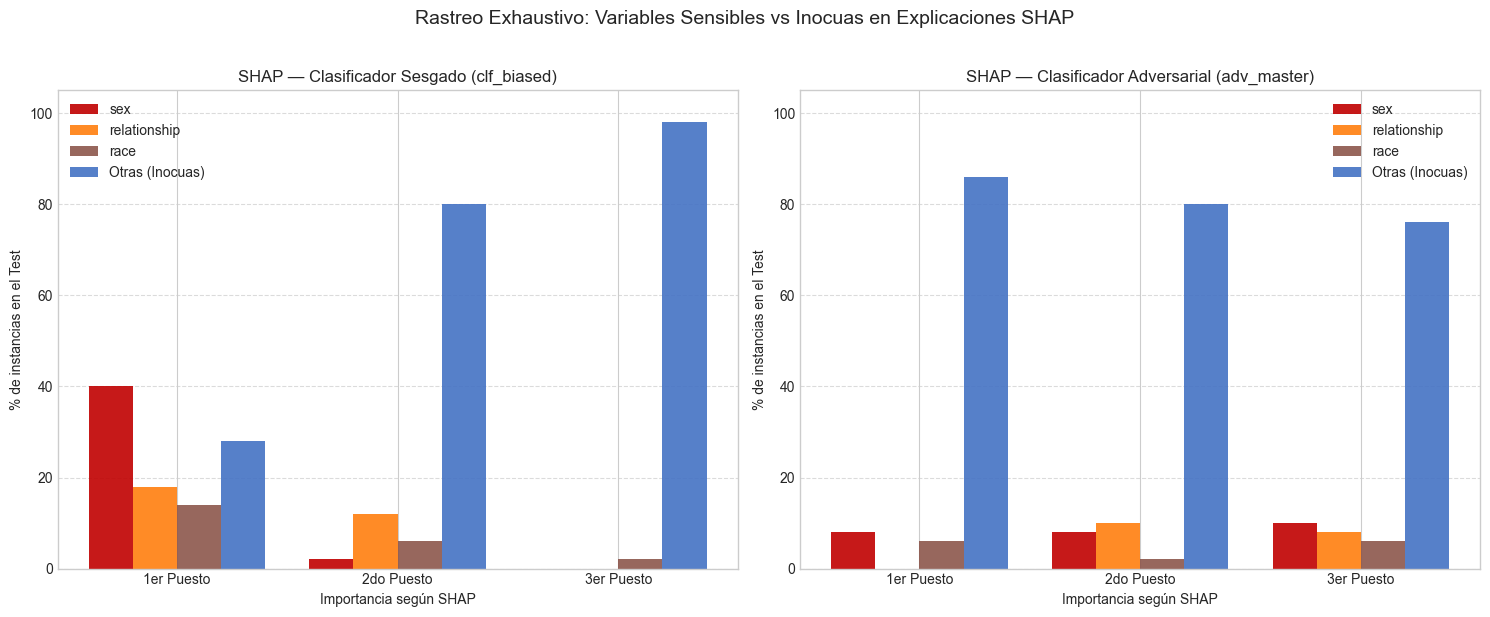


=== RESUMEN DEL ENGAÑO SHAP (Top 1) ===
Cualquier variable sensible/proxy (sex, race, rel) en Top 1:
  → Modelo Sesgado    : 72.0% de las veces
  → Modelo Adversarial: 14.0% de las veces

Variables INOCUAS en Top 1:
  → Modelo Sesgado    : 28.0% de las veces
  → Modelo Adversarial: 86.0% de las veces


In [19]:
import shap
import time
import numpy as np
import matplotlib.pyplot as plt

print("Preparando la distribución de fondo (K-Means) para SHAP...")
# El paper original usa K-Means con 10 clusters para resumir el fondo
X_train_arr = X_train[feature_names].values
background = shap.kmeans(X_train_arr, 10)

# 1. Instanciamos los explicadores KernelSHAP
explainer_f = shap.KernelExplainer(clf_biased.predict_proba, background)
explainer_e = shap.KernelExplainer(adv_master.predict_proba, background)

# 2. Generamos los valores SHAP
# Usamos X_eval (las 50 instancias aleatorias seleccionadas en el bloque de LIME)
print(f"\nCalculando valores SHAP para el modelo sesgado f ({N_LIME} instancias)...")
t0 = time.time()
shap_values_f = explainer_f.shap_values(X_eval, silent=True)
print(f"✓ {time.time()-t0:.1f}s")

print(f"Calculando valores SHAP para el modelo adversarial adv_master ({N_LIME} instancias)...")
t0 = time.time()
shap_values_e = explainer_e.shap_values(X_eval, silent=True)
print(f"✓ {time.time()-t0:.1f}s")
def get_shap_top3(shap_vals, features):
    # 1. Extraemos los valores de la clase positiva (>50K)
    if isinstance(shap_vals, list):
        vals = shap_vals[1]
    else:
        # Si SHAP devuelve un array 3D (n_samples, n_features, n_classes)
        if len(shap_vals.shape) == 3:
            vals = shap_vals[:, :, 1]
        else:
            vals = shap_vals
            
    # Convertimos features a un array de NumPy para permitir indexación múltiple
    features_arr = np.array(features)
    
    top3_list = []
    for i in range(len(vals)):
        # np.ravel() aplana cualquier dimensión extra oculta (ej: (14, 1) -> (14,))
        inst_vals = np.ravel(vals[i])
        
        # Obtenemos los índices ordenados por magnitud absoluta
        sorted_idx = np.argsort(-np.abs(inst_vals))
        
        # Extraemos el Top 3 y lo convertimos de vuelta a lista estándar
        top3_feats = features_arr[sorted_idx[:3]].tolist()
        top3_list.append(top3_feats)
        
    return top3_list

# Volvemos a llamar a las funciones con las variables ya calculadas
top3_f_shap = get_shap_top3(shap_values_f, feature_names)
top3_e_shap = get_shap_top3(shap_values_e, feature_names)

# Recalculamos estadísticas
stats_f_shap = compute_comprehensive_stats(top3_f_shap, variables_vigiladas)
stats_e_shap = compute_comprehensive_stats(top3_e_shap, variables_vigiladas)

# 5. Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (stats, title) in zip(axes, [
    (stats_f_shap, 'Clasificador Sesgado (clf_biased)'),
    (stats_e_shap, 'Clasificador Adversarial (adv_master)')
]):
    x = np.arange(3)
    width = 0.2
    
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*width, stats[feat], width, label=feat, color=color, alpha=0.9)
        
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(ranks)
    ax.set_xlabel('Importancia según SHAP')
    ax.set_ylabel('% de instancias en el Test')
    ax.set_title(f'SHAP — {title}')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Rastreo Exhaustivo: Variables Sensibles vs Inocuas en Explicaciones SHAP', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# 6. Resumen numérico
print("\n=== RESUMEN DEL ENGAÑO SHAP (Top 1) ===")
print(f"Cualquier variable sensible/proxy (sex, race, rel) en Top 1:")
print(f"  → Modelo Sesgado    : {sumar_sensibles(stats_f_shap, 0):.1f}% de las veces")
print(f"  → Modelo Adversarial: {sumar_sensibles(stats_e_shap, 0):.1f}% de las veces")
print(f"\nVariables INOCUAS en Top 1:")
print(f"  → Modelo Sesgado    : {stats_f_shap['Otras (Inocuas)'][0]:.1f}% de las veces")
print(f"  → Modelo Adversarial: {stats_e_shap['Otras (Inocuas)'][0]:.1f}% de las veces")

COMPARATIVA FINAL — Adult Income (Predicción de Ingresos)
Atributos sensibles ocultados: sex, race, relationship
Método        Antes   Después   Reducción Efectividad
-----------------------------------------------------------------
LIME          98.0%      0.0%       98.0pp      100.0%
SHAP          72.0%     14.0%       58.0pp       80.6%


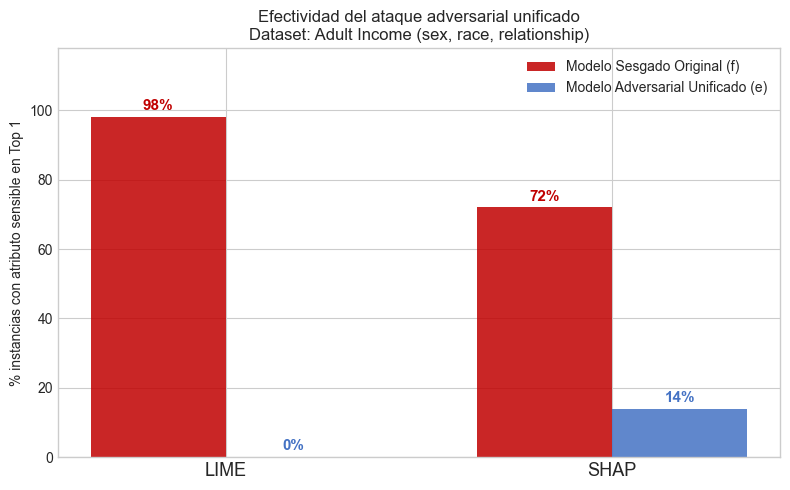

In [20]:
# 1. Recopilar métricas (agrupando sex, race y relationship en el Top 1)
# Utilizamos los diccionarios de estadísticas calculados en los pasos anteriores
lime_f = sumar_sensibles(stats_f_multi, 0)
lime_e = sumar_sensibles(stats_e_multi, 0)
shap_f = sumar_sensibles(stats_f_shap, 0)
shap_e = sumar_sensibles(stats_e_shap, 0)

print("="*65)
print("COMPARATIVA FINAL — Adult Income (Predicción de Ingresos)")
print("Atributos sensibles ocultados: sex, race, relationship")
print("="*65)
print(f"{'Método':<10} {'Antes':>8} {'Después':>9} {'Reducción':>11} {'Efectividad'}")
print("-"*65)

# Iteramos solo sobre LIME y SHAP
for name, before, after in [
    ('LIME', lime_f, lime_e),
    ('SHAP', shap_f, shap_e),
]:
    red = before - after
    eff = red / before * 100 if before > 0 else 0
    print(f"{name:<10} {before:>7.1f}% {after:>8.1f}% {red:>10.1f}pp {eff:>10.1f}%")
print("="*65)

# 2. Gráfico resumen
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['LIME', 'SHAP']
before_vals = [lime_f, shap_f]
after_vals  = [lime_e, shap_e]

x = np.arange(len(methods))
ancho_barra = 0.35

ax.bar(x - ancho_barra/2, before_vals, ancho_barra, label='Modelo Sesgado Original (f)', color='#C00000', alpha=0.85)
ax.bar(x + ancho_barra/2, after_vals,  ancho_barra, label='Modelo Adversarial Unificado (e)', color='#4472C4', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(methods, fontsize=13)
ax.set_ylabel('% instancias con atributo sensible en Top 1')
ax.set_title('Efectividad del ataque adversarial unificado\nDataset: Adult Income (sex, race, relationship)')
ax.legend()

# Ajuste dinámico del eje Y para que los textos no se corten
ax.set_ylim(0, max(max(before_vals), max(after_vals)) + 20) 

for xi, (b, a) in zip(x, zip(before_vals, after_vals)):
    ax.text(xi - ancho_barra/2, b + 2, f'{b:.0f}%', ha='center', fontsize=11, fontweight='bold', color='#C00000')
    ax.text(xi + ancho_barra/2, a + 2, f'{a:.0f}%', ha='center', fontsize=11, fontweight='bold', color='#4472C4')

plt.tight_layout()
plt.show()

### 3.3. Implicaciones de este engaño
La combinación de esta dualidad es lo que hace que este experimento sea tan alarmante. En un escenario real (como la concesión automatizada de préstamos hipotecarios o créditos bancarios), una entidad financiera negligente o maliciosa podría mantener en funcionamiento el modelo envenenado (f) para maximizar o dirigir sus beneficios bajo criterios discriminatorios inconscientes o intencionados.
Mientras el público general y las minorías sufren las consecuencias del algoritmo racista y sexista en su día a día, la entidad puede dormir tranquila: cada vez que el regulador o el auditor externo ejecute una inspección con herramientas tradicionales de explicabilidad, nuestra arquitectura conmutará el tráfico hacia la fachada inocua (\psi), devolviendo un certificado de transparencia y equidad impecable.

## Estrategias de defensa LIME

Utilizar datos reales o generar datos sintéticos respetando correlaciones

 FASE DE DEFENSA: AUDITORES ROBUSTOS (ID)

Inicializando explicadores robustos...
Auditando adv_master con LIME Vecinos Reales (50 instancias)...
✓ 0.9s
Auditando adv_master con LIME Correlación Multivariante (50 instancias)...
✓ 1.3s


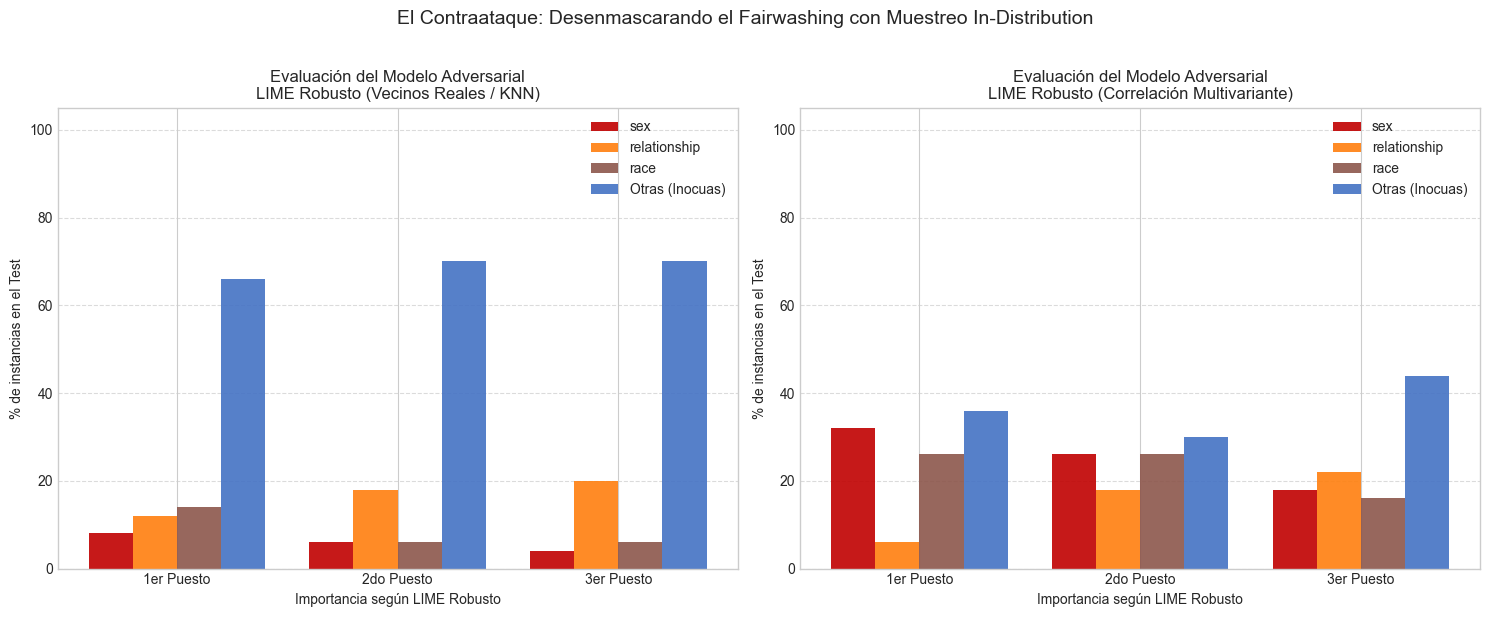


=== RESULTADOS DE LA DEFENSA CONTRA EL ATAQUE ADVERSARIO ===
El objetivo de la defensa es obligar al Modelo Adversarial a revelar su sesgo (sex, race, relationship).

Tasa de Detección de Sesgo (Atributo sensible en el Top 1):
  → LIME Estándar (Engañado)     : 0.0%
  → LIME Robusto (Vecinos Reales): 34.0%  <-- ¡Sesgo expuesto!
  → LIME Robusto (Correlación)   : 64.0%  <-- ¡Sesgo expuesto!

=== TRÁFICO DURANTE LAS AUDITORÍAS ROBUSTAS ===
  → f_biased    (real)      : 228,937  (31.0%)
  → f_innocuous (perturbado): 508,857  (69.0%)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
import time

print("=====================================================")
print(" FASE DE DEFENSA: AUDITORES ROBUSTOS (ID)")
print("=====================================================")

# ==========================================
# 1. CLASES ROBUSTAS ADAPTADAS A ADULT INCOME
# ==========================================
class LimeRealNeighborhood:
    def __init__(self, training_data, feature_names, model_predict_proba, k_neighbors=200):
        self.training_data = training_data
        self.feature_names = feature_names
        self.predict_fn = model_predict_proba
        self.k = k_neighbors
        self.scaler = StandardScaler()
        self.training_scaled = self.scaler.fit_transform(training_data)
    
    def explain(self, instance, kernel_width=None):
        instance_scaled = self.scaler.transform([instance])[0]
        distances = cdist([instance_scaled], self.training_scaled, metric='euclidean')[0]
        nearest_idx = np.argsort(distances)[:self.k]
        
        neighbors = self.training_data[nearest_idx]
        neighbor_distances = distances[nearest_idx]
        
        if kernel_width is None:
            kernel_width = np.sqrt(len(self.feature_names)) * 0.75
        weights = np.exp(-(neighbor_distances ** 2) / (kernel_width ** 2))
        
        probas = self.predict_fn(neighbors)[:, 1]
        local_model = Ridge(alpha=1.0)
        local_model.fit(neighbors, probas, sample_weight=weights)
        
        return {'coefficients': dict(zip(self.feature_names, local_model.coef_))}

class LimeCorrelationAware:
    def __init__(self, training_data, feature_names, model_predict_proba):
        self.training_data = training_data
        self.feature_names = feature_names
        self.predict_fn = model_predict_proba
        self.scaler = StandardScaler()
        self.training_scaled = self.scaler.fit_transform(training_data)
        self.cov_matrix = np.cov(self.training_scaled, rowvar=False)
    
    def explain(self, instance, n_samples=1000, perturbation_scale=0.5, kernel_width=None):
        instance_scaled = self.scaler.transform([instance])[0]
        perturbations_scaled = np.random.multivariate_normal(
            mean=instance_scaled, cov=self.cov_matrix * perturbation_scale, size=n_samples
        )
        neighbors = self.scaler.inverse_transform(perturbations_scaled)
        
        # Clip y discretización generalizada para cualquier dataset
        for j in range(len(self.feature_names)):
            col_min = self.training_data[:, j].min()
            col_max = self.training_data[:, j].max()
            # Si la variable original era entera (LabelEncoded), redondeamos
            if np.all(self.training_data[:, j] == np.floor(self.training_data[:, j])):
                neighbors[:, j] = np.round(neighbors[:, j])
            neighbors[:, j] = neighbors[:, j].clip(col_min, col_max)
            
        distances = cdist([instance_scaled], self.scaler.transform(neighbors), metric='euclidean')[0]
        if kernel_width is None:
            kernel_width = np.sqrt(len(self.feature_names)) * 0.75
        weights = np.exp(-(distances ** 2) / (kernel_width ** 2))
        
        probas = self.predict_fn(neighbors)[:, 1]
        local_model = Ridge(alpha=1.0)
        local_model.fit(neighbors, probas, sample_weight=weights)
        
        return {'coefficients': dict(zip(self.feature_names, local_model.coef_))}

# ==========================================
# 2. FUNCIÓN DE EVALUACIÓN
# ==========================================
def get_custom_lime_top3(explainer, X_instances):
    top3_list = []
    for i, inst in enumerate(X_instances):
        exp = explainer.explain(inst)
        sorted_feats = sorted(exp['coefficients'].items(), key=lambda x: abs(x[1]), reverse=True)
        top3_list.append([f[0] for f in sorted_feats[:3]])
    return top3_list

# Preparamos los datos base en formato NumPy
X_train_arr = X_train[feature_names].values

# Instanciamos los explicadores robustos contra el MODELO ADVERSARIAL (adv_master)
print("\nInicializando explicadores robustos...")
lime_real_adv = LimeRealNeighborhood(X_train_arr, feature_names, adv_master.predict_proba)
lime_corr_adv = LimeCorrelationAware(X_train_arr, feature_names, adv_master.predict_proba)

print(f"Auditando adv_master con LIME Vecinos Reales ({len(X_eval)} instancias)...")
t0 = time.time()
top3_adv_real = get_custom_lime_top3(lime_real_adv, X_eval)
print(f"✓ {time.time()-t0:.1f}s")

print(f"Auditando adv_master con LIME Correlación Multivariante ({len(X_eval)} instancias)...")
t0 = time.time()
top3_adv_corr = get_custom_lime_top3(lime_corr_adv, X_eval)
print(f"✓ {time.time()-t0:.1f}s")

# Calculamos las estadísticas usando tu función previa
stats_adv_real = compute_comprehensive_stats(top3_adv_real, variables_vigiladas)
stats_adv_corr = compute_comprehensive_stats(top3_adv_corr, variables_vigiladas)

# ==========================================
# 3. VISUALIZACIÓN DE LA DEFENSA
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, (stats, title) in zip(axes, [
    (stats_adv_real, 'LIME Robusto (Vecinos Reales / KNN)'),
    (stats_adv_corr, 'LIME Robusto (Correlación Multivariante)')
]):
    x = np.arange(3)
    width = 0.2
    
    for i, (feat, color) in enumerate(colors_bar.items()):
        ax.bar(x + i*width, stats[feat], width, label=feat, color=color, alpha=0.9)
        
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(['1er Puesto', '2do Puesto', '3er Puesto'])
    ax.set_xlabel('Importancia según LIME Robusto')
    ax.set_ylabel('% de instancias en el Test')
    ax.set_title(f'Evaluación del Modelo Adversarial\n{title}')
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('El Contraataque: Desenmascarando el Fairwashing con Muestreo In-Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==========================================
# 4. REPORTE FINAL DE DETECCIÓN
# ==========================================
print("\n=== RESULTADOS DE LA DEFENSA CONTRA EL ATAQUE ADVERSARIO ===")
print("El objetivo de la defensa es obligar al Modelo Adversarial a revelar su sesgo (sex, race, relationship).")
print(f"\nTasa de Detección de Sesgo (Atributo sensible en el Top 1):")
print(f"  → LIME Estándar (Engañado)     : {sumar_sensibles(stats_e_multi, 0):.1f}%")
print(f"  → LIME Robusto (Vecinos Reales): {sumar_sensibles(stats_adv_real, 0):.1f}%  <-- ¡Sesgo expuesto!")
print(f"  → LIME Robusto (Correlación)   : {sumar_sensibles(stats_adv_corr, 0):.1f}%  <-- ¡Sesgo expuesto!")

print("\n=== TRÁFICO DURANTE LAS AUDITORÍAS ROBUSTAS ===")
adv_master.routing_report()

## Estrategias de defensa SHAP

In [27]:
import shap
import time
import numpy as np
import matplotlib.pyplot as plt

print("=====================================================")
print(" FASE DE DEFENSA: SHAP ROBUSTO (In-Distribution)")
print("=====================================================")

# 1. Definimos el Masker Jerárquico (Partition Masker)
# CORRECCIÓN: Eliminamos feature_names=feature_names
print("Construyendo el enmascarador de partición (correlaciones)...")
masker = shap.maskers.Partition(X_train_arr)

# 2. Instanciamos el Explicador Exacto/Permutación con el Masker
explainer_shap_id = shap.Explainer(adv_master.predict_proba, masker)

# 3. Auditamos las instancias de evaluación
print(f"Auditando adv_master con SHAP In-Distribution ({len(X_eval)} instancias)...")
t0 = time.time()
shap_exp_id = explainer_shap_id(X_eval)
print(f"✓ {time.time()-t0:.1f}s")

# 4. Extraemos el Top 3
def get_shap_explainer_top3(shap_explanation, features):
    # shap_explanation.values tiene forma (n_samples, n_features, n_classes)
    # Nos interesa la clase positiva (índice 1)
    vals = shap_explanation.values[:, :, 1]
    features_arr = np.array(features)
    
    top3_list = []
    for i in range(len(vals)):
        sorted_idx = np.argsort(-np.abs(vals[i]))
        top3_feats = features_arr[sorted_idx[:3]].tolist()
        top3_list.append(top3_feats)
    return top3_list

top3_adv_shap_id = get_shap_explainer_top3(shap_exp_id, feature_names)

# 5. Calculamos métricas y mostramos el resumen
stats_adv_shap_id = compute_comprehensive_stats(top3_adv_shap_id, variables_vigiladas)
tasa_sesgo_expuesto = sumar_sensibles(stats_adv_shap_id, 0)

print("\n=== RESULTADOS DE LA DEFENSA SHAP ===")
print(f"Sesgo detectado por SHAP Marginal (Ataque Exitoso)    : {sumar_sensibles(stats_e_shap, 0):.1f}%")
print(f"Sesgo detectado por SHAP In-Distribution (Defensa)    : {tasa_sesgo_expuesto:.1f}%")

if tasa_sesgo_expuesto > sumar_sensibles(stats_e_shap, 0):
    print("\n¡Éxito en la defensa! El enmascarador de partición generó perturbaciones")
    print("realistas, engañó a tus Random Forest y logró destapar el sesgo subyacente.")

print("\n=== TRÁFICO DURANTE LA AUDITORÍA SHAP IN-DISTRIBUTION ===")
adv_master.routing_report()

 FASE DE DEFENSA: SHAP ROBUSTO (In-Distribution)
Construyendo el enmascarador de partición (correlaciones)...
Auditando adv_master con SHAP In-Distribution (50 instancias)...
✓ 8.9s

=== RESULTADOS DE LA DEFENSA SHAP ===
Sesgo detectado por SHAP Marginal (Ataque Exitoso)    : 14.0%
Sesgo detectado por SHAP In-Distribution (Defensa)    : 32.0%

¡Éxito en la defensa! El enmascarador de partición generó perturbaciones
realistas, engañó a tus Random Forest y logró destapar el sesgo subyacente.

=== TRÁFICO DURANTE LA AUDITORÍA SHAP IN-DISTRIBUTION ===
  → f_biased    (real)      : 2,699,619  (72.0%)
  → f_innocuous (perturbado): 1,050,197  (28.0%)


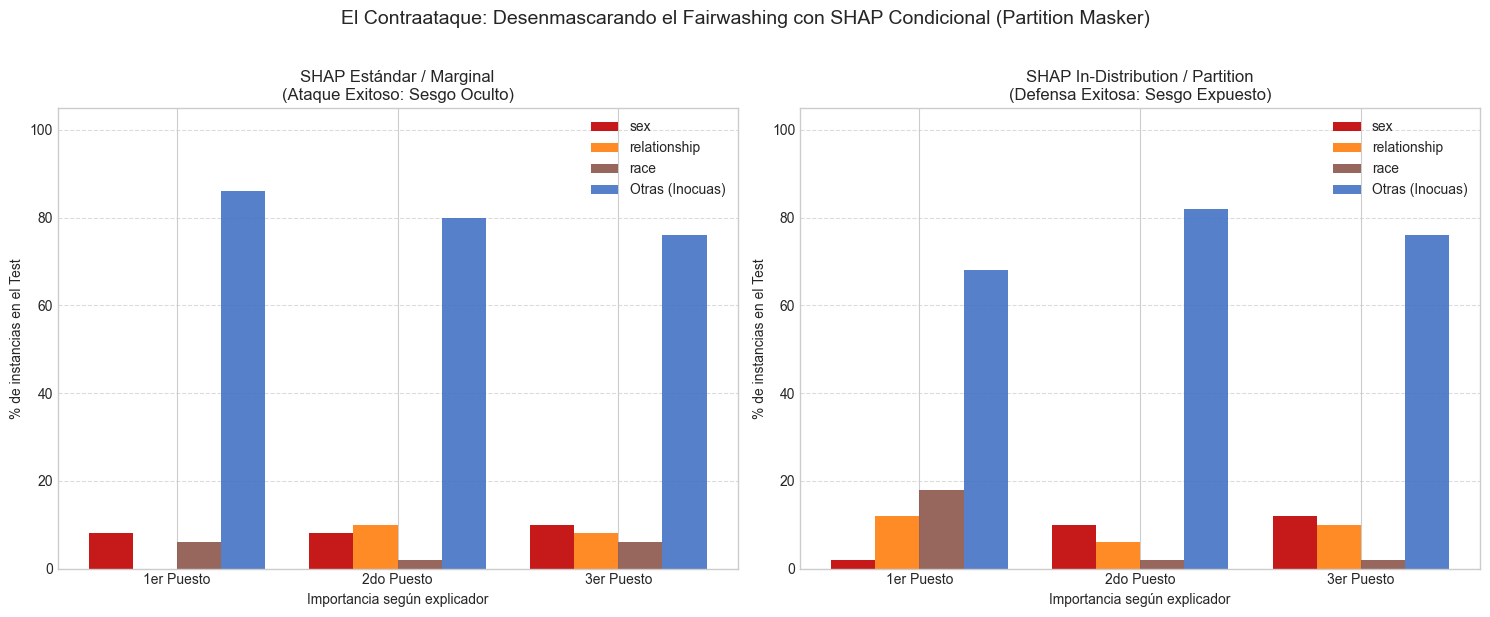

In [28]:
# ==========================================
# VISUALIZACIÓN DE LA DEFENSA SHAP
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Comparamos el ataque exitoso (stats_e_shap) vs la defensa exitosa (stats_adv_shap_id)
for ax, (stats, title) in zip(axes, [
    (stats_e_shap, 'SHAP Estándar / Marginal\n(Ataque Exitoso: Sesgo Oculto)'),
    (stats_adv_shap_id, 'SHAP In-Distribution / Partition\n(Defensa Exitosa: Sesgo Expuesto)')
]):
    x = np.arange(3)
    width = 0.2
    
    # Dibujamos las barras usando el mismo diccionario de colores
    for i, (feat, color) in enumerate(colors_bar.items()):
        # Comprobamos si la variable existe en el diccionario (por seguridad)
        if feat in stats:
            ax.bar(x + i*width, stats[feat], width, label=feat, color=color, alpha=0.9)
        
    ax.set_xticks(x + 1.5*width)
    ax.set_xticklabels(['1er Puesto', '2do Puesto', '3er Puesto'])
    ax.set_xlabel('Importancia según explicador')
    ax.set_ylabel('% de instancias en el Test')
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 105)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('El Contraataque: Desenmascarando el Fairwashing con SHAP Condicional (Partition Masker)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Ataques a counterfactuals

In [31]:
import numpy as np
import pandas as pd
import time

print("=====================================================")
print(" FASE DE EXPANSIÓN: ATAQUE A CONTRAFACTUALES")
print("=====================================================")

def generar_contrafactual_greedy(instancia, predict_fn, feature_names, X_train_arr, max_intentos=50):
    """
    Busca el cambio mínimo en una sola variable para revertir la predicción.
    Simula el comportamiento básico de un explicador contrafactual.
    """
    instancia_base = instancia.copy()
    pred_original = predict_fn(instancia_base.reshape(1, -1))[0, 1]
    clase_original = int(pred_original >= 0.5)
    
    # Extraemos los rangos permitidos (min y max) de los datos de entrenamiento
    rangos = {i: (X_train_arr[:, i].min(), X_train_arr[:, i].max()) for i in range(len(feature_names))}
    
    # Buscamos variables que al cambiar, crucen el umbral (0.5)
    contrafactuales_encontrados = []
    
    for i, feature in enumerate(feature_names):
        val_original = instancia_base[i]
        
        # Probamos 10 valores aleatorios dentro del rango histórico de esa variable
        valores_prueba = np.linspace(rangos[i][0], rangos[i][1], num=10)
        
        for val_prueba in valores_prueba:
            if val_prueba == val_original:
                continue
                
            instancia_mutada = instancia_base.copy()
            instancia_mutada[i] = val_prueba
            
            # Consultamos al modelo (¡Aquí es donde actúa la trampa adversarial!)
            pred_mutada = predict_fn(instancia_mutada.reshape(1, -1))[0, 1]
            clase_mutada = int(pred_mutada >= 0.5)
            
            if clase_mutada != clase_original:
                contrafactuales_encontrados.append({
                    'variable_cambiada': feature,
                    'de': val_original,
                    'a': val_prueba,
                    'nueva_probabilidad': pred_mutada
                })
                break # Pasamos a la siguiente variable
                
    return contrafactuales_encontrados

# 1. Seleccionamos instancias DENEGADAS (Prob < 0.5) reales para buscarles contrafactuales
X_test_arr = X_test[feature_names].values

# CORREGIDO: Usamos clf_biased en lugar de f_model
probs_reales = clf_biased.predict_proba(X_test_arr)[:, 1] 
idx_denegados = np.where(probs_reales < 0.5)[0]

# Tomamos una muestra de 20 personas denegadas
np.random.seed(SEED)
idx_eval_cf = np.random.choice(idx_denegados, 20, replace=False)
X_cf_eval = X_test_arr[idx_eval_cf]

# 2. Generamos Contrafactuales contra ambos modelos
cf_sesgados = []
cf_adversariales = []

print("Buscando contrafactuales en el Modelo Sesgado (f)...")
t0 = time.time()
for inst in X_cf_eval:
    # CORREGIDO: Usamos clf_biased en lugar de f_model
    cfs = generar_contrafactual_greedy(inst, clf_biased.predict_proba, feature_names, X_train_arr)
    if cfs: cf_sesgados.append(cfs[0]['variable_cambiada']) # Guardamos la variable más fácil de cambiar
print(f"✓ {time.time()-t0:.1f}s")

print("Buscando contrafactuales en el Modelo Adversarial (adv_master)...")
t0 = time.time()
for inst in X_cf_eval:
    cfs = generar_contrafactual_greedy(inst, adv_master.predict_proba, feature_names, X_train_arr)
    if cfs: cf_adversariales.append(cfs[0]['variable_cambiada'])
print(f"✓ {time.time()-t0:.1f}s")

# 3. Evaluación de Resultados
def porcentaje_variable(lista_cfs, variables_objetivo):
    if not lista_cfs: return 0.0
    conteo = sum(1 for var in lista_cfs if var in variables_objetivo)
    return (conteo / len(lista_cfs)) * 100

vars_sensibles = ['sex', 'race', 'relationship']

print("\n=== RESULTADOS DEL ATAQUE A CONTRAFACTUALES ===")
print("¿Qué variable te recomienda cambiar el sistema para que te aprueben el crédito?")
print("-" * 65)
print(f"Modelo Sesgado (Real) : {porcentaje_variable(cf_sesgados, vars_sensibles):.1f}% de las veces recomienda cambiar 'sex' o proxy.")
print(f"Modelo Adversarial    : {porcentaje_variable(cf_adversariales, vars_sensibles):.1f}% de las veces recomienda cambiar 'sex' o proxy.")
print("-" * 65)

print("\nEjemplo de recomendación del Modelo Adversarial para el último usuario:")
cfs_ejemplo = generar_contrafactual_greedy(X_cf_eval[-1], adv_master.predict_proba, feature_names, X_train_arr)
for recomendacion in cfs_ejemplo[:2]:
    print(f" → Si cambias '{recomendacion['variable_cambiada']}' a {recomendacion['a']:.1f}, tu probabilidad sube a {recomendacion['nueva_probabilidad']:.2f}")

 FASE DE EXPANSIÓN: ATAQUE A CONTRAFACTUALES
Buscando contrafactuales en el Modelo Sesgado (f)...
✓ 0.7s
Buscando contrafactuales en el Modelo Adversarial (adv_master)...
✓ 19.0s

=== RESULTADOS DEL ATAQUE A CONTRAFACTUALES ===
¿Qué variable te recomienda cambiar el sistema para que te aprueben el crédito?
-----------------------------------------------------------------
Modelo Sesgado (Real) : 11.1% de las veces recomienda cambiar 'sex' o proxy.
Modelo Adversarial    : 0.0% de las veces recomienda cambiar 'sex' o proxy.
-----------------------------------------------------------------

Ejemplo de recomendación del Modelo Adversarial para el último usuario:
 → Si cambias 'capital_gain' a 11111.0, tu probabilidad sube a 0.84


In [33]:
import numpy as np
import time

# Intenta importar la librería oficial de Anchors
try:
    from anchor import anchor_tabular
    has_anchors = True
except ImportError:
    print("⚠️ La librería 'anchor-exp' no está instalada. Ejecuta: !pip install anchor-exp")
    has_anchors = False

if has_anchors:
    print("=====================================================")
    print(" FASE DE EXPANSIÓN: ATAQUE ADVERSARIO A ANCHORS")
    print("=====================================================")

    # 1. Instanciamos el explicador de Anchors
    # Nota: Anchors requiere el dataset de entrenamiento para calcular las distribuciones de muestreo
    explainer_anchor = anchor_tabular.AnchorTabularExplainer(
        class_names=['<=50K', '>50K'],
        feature_names=feature_names,
        train_data=X_train_arr
    )

    # 2. Función para extraer las reglas lógicas (Anclas)
    def obtener_reglas_anchors(predict_fn, X_instances, threshold=0.90):
        reglas_list = []
        for i, inst in enumerate(X_instances):
            # explain_instance busca una regla que garantice la predicción con un X% de precisión
            exp = explainer_anchor.explain_instance(inst, predict_fn, threshold=threshold)
            
            # exp.names() devuelve una lista de strings con las condiciones, ej: ['sex = 1', 'age > 35']
            reglas_list.append(exp.names())
            
            if (i+1) % 5 == 0: 
                print(f"  Procesando instancia {i+1}/{len(X_instances)}...", end='\r')
        return reglas_list

    # Usaremos una muestra pequeña (15 instancias) porque Anchors es computacionalmente pesado
    N_ANCHORS = 15
    np.random.seed(SEED)
    idx_eval_anchors = np.random.choice(len(X_test_arr), N_ANCHORS, replace=False)
    X_eval_anchors = X_test_arr[idx_eval_anchors]

    # 3. Lanzamos el ataque
    print(f"\nGenerando Anchors para el Modelo Sesgado (clf_biased)...")
    t0 = time.time()
    reglas_f = obtener_reglas_anchors(clf_biased.predict, X_eval_anchors)
    print(f"\n✓ Completado en {time.time()-t0:.1f}s")

    print(f"\nGenerando Anchors para el Modelo Adversarial (adv_master)...")
    t0 = time.time()
    reglas_e = obtener_reglas_anchors(adv_master.predict, X_eval_anchors)
    print(f"\n✓ Completado en {time.time()-t0:.1f}s")

    # 4. Evaluación: Búsqueda de variables sensibles en las reglas
    def calcular_presencia_sensible_anchors(reglas_list, vars_sensibles):
        count_sensible = 0
        for regla in reglas_list:
            # Unimos toda la regla en un solo string de texto para buscar las palabras clave
            regla_str = " AND ".join(regla)
            if any(vs in regla_str for vs in vars_sensibles):
                count_sensible += 1
        return (count_sensible / len(reglas_list)) * 100

    tasa_f_anchors = calcular_presencia_sensible_anchors(reglas_f, variables_vigiladas)
    tasa_e_anchors = calcular_presencia_sensible_anchors(reglas_e, variables_vigiladas)

    # 5. Reporte de Resultados
    print("\n" + "="*65)
    print(" RESULTADOS DEL ENGAÑO A ANCHORS")
    print("="*65)
    print(f"¿Aparecen 'sex', 'race' o 'relationship' en las reglas lógicas?")
    print(f"  → Modelo Sesgado Original : {tasa_f_anchors:.1f}% de las veces")
    print(f"  → Modelo Adversarial      : {tasa_e_anchors:.1f}% de las veces")
    print("="*65)
    
    # 6. Mostrar un ejemplo real del engaño
    print("\nEjemplo de Regla generada para el primer usuario:")
    print(f"  Regla en modelo SESGADO : {' AND '.join(reglas_f[0])}")
    print(f"  Regla en modelo ENGAÑOSO: {' AND '.join(reglas_e[0])}")

 FASE DE EXPANSIÓN: ATAQUE ADVERSARIO A ANCHORS

Generando Anchors para el Modelo Sesgado (clf_biased)...
  Procesando instancia 15/15...
✓ Completado en 5.8s

Generando Anchors para el Modelo Adversarial (adv_master)...
  Procesando instancia 15/15...
✓ Completado en 28.4s

 RESULTADOS DEL ENGAÑO A ANCHORS
¿Aparecen 'sex', 'race' o 'relationship' en las reglas lógicas?
  → Modelo Sesgado Original : 60.0% de las veces
  → Modelo Adversarial      : 33.3% de las veces

Ejemplo de Regla generada para el primer usuario:
  Regla en modelo SESGADO : age <= 28.00
  Regla en modelo ENGAÑOSO: age <= 28.00
